In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [2]:
path = r"C:\Users\Noble Adike\Desktop\Coding\KPMG\kpmg-1a\data\harvard\Year 2 (Jun 2023 - May 2024)\Zone_temp_hourly\48190906_Zone_temp_hourly.csv"
df = pd.read_csv(path)
df.head()

,Timestamp,Z11_temp,Z12+13_temp,Z14_temp,Z15+16_temp,Z17_temp,Z1_temp,Z21_temp,Z22+23_temp,Z24_temp,Z25+26+27_temp,Z2_temp,Z31_temp,Z32_temp,Z33_temp,Z3_temp,Z4_temp,Z5_temp
0,2023-06-01 00:00:00-04:00,23.126000,23.365666,21.626667,22.963999,22.915667,23.071333,23.266667,22.878666,23.094333,23.117333,25.497667,23.720667,23.817000,23.364333,22.796000,23.076333,21.646000
1,2023-06-01 01:00:00-04:00,22.892667,22.971667,21.443000,22.774000,22.789333,23.038667,23.249333,22.659667,22.972667,23.102667,25.369000,23.587000,23.594667,23.281667,22.749333,23.037334,21.579333
2,2023-06-01 02:00:00-04:00,22.898667,22.943000,21.392666,22.647667,22.661667,23.075000,23.343666,22.738000,23.305000,23.347333,25.277667,23.180333,23.415000,22.988667,22.724333,23.093667,21.521667
3,2023-06-01 03:00:00-04:00,22.924667,23.039000,21.361333,22.523667,22.568667,23.117667,23.126667,22.595333,23.213667,23.177000,25.222666,23.131667,23.318667,23.062334,22.693001,23.087667,21.465666
4,2023-06-01 04:00:00-04:00,22.858667,23.019334,21.302333,22.401666,22.472000,23.112333,23.052666,22.493333,22.994667,23.101667,25.122667,23.098000,23.192000,23.047333,22.654333,23.063666,21.413000


In [12]:
df.describe()

,Z11_temp,Z12+13_temp,Z14_temp,Z15+16_temp,Z17_temp,Z1_temp,Z21_temp,Z22+23_temp,Z24_temp,Z25+26+27_temp,Z2_temp,Z31_temp,Z32_temp,Z33_temp,Z3_temp,Z4_temp,Z5_temp
count,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000
mean,23.017922,23.407513,21.201209,22.429248,22.036949,23.026602,23.331694,22.845667,23.527521,23.424621,24.482158,23.966754,23.071776,23.082205,21.547623,22.827787,21.600340
std,0.614782,0.637638,0.680816,0.644988,0.983981,0.621487,0.973671,0.875760,0.960246,0.855372,0.859323,1.363312,1.205514,1.410433,0.951191,0.604981,1.008719
min,21.695959,22.039542,19.673666,21.005374,19.403833,21.691542,21.003042,20.862583,21.311499,21.494000,22.352123,20.543125,20.039043,19.426084,19.267500,21.504166,18.958707
25%,22.675583,23.052917,20.797916,22.054250,21.373333,22.671667,22.727667,22.332833,22.947250,22.911000,23.974249,23.067000,22.267917,22.092584,20.800000,22.483667,20.979333
50%,22.961833,23.320500,21.100667,22.363500,21.807333,23.022834,23.159667,22.725000,23.338500,23.288667,24.548334,23.720833,22.763667,22.716000,21.469666,22.823666,21.543334
75%,23.328667,23.728500,21.547417,22.753500,22.686333,23.325083,23.877417,23.313000,24.037750,23.855666,25.055667,24.749583,23.753833,23.870250,22.230083,23.136667,22.326417
max,24.308291,24.741874,22.671668,23.802376,24.655833,24.305208,25.602041,24.783250,25.673501,25.272666,26.677793,27.273459,25.982708,26.536749,24.375208,24.116167,24.347042


In [13]:
df.isna().sum()

Z11_temp          0
Z12+13_temp       0
Z14_temp          0
Z15+16_temp       0
Z17_temp          0
Z1_temp           0
Z21_temp          0
Z22+23_temp       0
Z24_temp          0
Z25+26+27_temp    0
Z2_temp           0
Z31_temp          0
Z32_temp          0
Z33_temp          0
Z3_temp           0
Z4_temp           0
Z5_temp           0
dtype: int64

In [5]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df = df.set_index('Timestamp')

C:\Users\Noble Adike\AppData\Local\Temp\ipykernel_3084\330094659.py:1: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df['Timestamp'] = pd.to_datetime(df['Timestamp'])


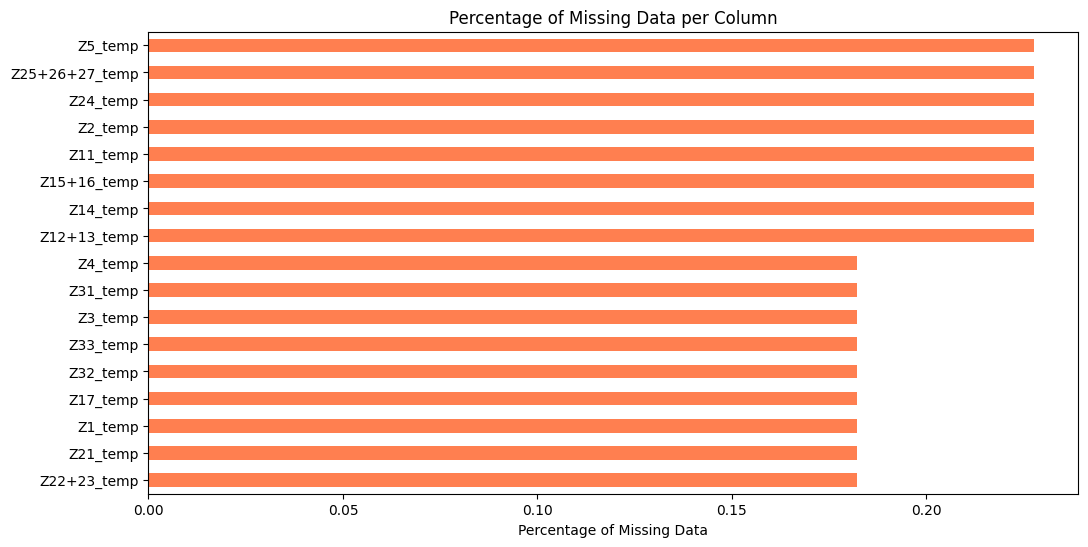

In [6]:
missing_percent = df.isnull().mean() * 100
missing_percent = missing_percent[missing_percent > 0]  # Only show columns with missing data
missing_percent.sort_values().plot(kind='barh', figsize=(12, 6), color='coral')
plt.title('Percentage of Missing Data per Column')
plt.xlabel('Percentage of Missing Data')
plt.show()

In [7]:

def handle_missing_data(column):

    # Count the number of missing values in the column
    missing_count = df[column].isna().sum()
    total_rows = len(df)
    
    print(f"Missing values in '{column}': {missing_count} out of {total_rows} ({(missing_count/total_rows)*100:.2f}%)")
    
    # If the missing data is a large percentage (e.g., more than 10%), use interpolation
    if missing_count > total_rows * 0.1:
        print(f"Handling missing data in '{column}' with interpolation...")
        # Interpolate the missing values using linear interpolation
        df[column] = df[column].interpolate(method='linear')
    else:
        # Otherwise, fill the missing data with the median (or mean) of the column
        print(f"Handling missing data in '{column}' with median imputation...")
        df[column] = df[column].fillna(df[column].median())
    
    return df[column]


for col in df.columns:
    if df[col].isna().sum() > 0:
        df[col] = handle_missing_data(col)

Missing values in 'Z11_temp': 20 out of 8784 (0.23%)
Handling missing data in 'Z11_temp' with median imputation...
Missing values in 'Z12+13_temp': 20 out of 8784 (0.23%)
Handling missing data in 'Z12+13_temp' with median imputation...
Missing values in 'Z14_temp': 20 out of 8784 (0.23%)
Handling missing data in 'Z14_temp' with median imputation...
Missing values in 'Z15+16_temp': 20 out of 8784 (0.23%)
Handling missing data in 'Z15+16_temp' with median imputation...
Missing values in 'Z17_temp': 16 out of 8784 (0.18%)
Handling missing data in 'Z17_temp' with median imputation...
Missing values in 'Z1_temp': 16 out of 8784 (0.18%)
Handling missing data in 'Z1_temp' with median imputation...
Missing values in 'Z21_temp': 16 out of 8784 (0.18%)
Handling missing data in 'Z21_temp' with median imputation...
Missing values in 'Z22+23_temp': 16 out of 8784 (0.18%)
Handling missing data in 'Z22+23_temp' with median imputation...
Missing values in 'Z24_temp': 20 out of 8784 (0.23%)
Handling mi

In [8]:
df.isna().sum()

Z11_temp          0
Z12+13_temp       0
Z14_temp          0
Z15+16_temp       0
Z17_temp          0
Z1_temp           0
Z21_temp          0
Z22+23_temp       0
Z24_temp          0
Z25+26+27_temp    0
Z2_temp           0
Z31_temp          0
Z32_temp          0
Z33_temp          0
Z3_temp           0
Z4_temp           0
Z5_temp           0
dtype: int64

In [9]:
df.shape

(8784, 17)

In [10]:
def treat_outliers_iqr(df):
    df_clean = df.copy()
    for col in df_clean.columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1


        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df_clean[col] = df_clean[col].clip(lower=lower_bound, upper=upper_bound)
    return df_clean
df = treat_outliers_iqr(df)

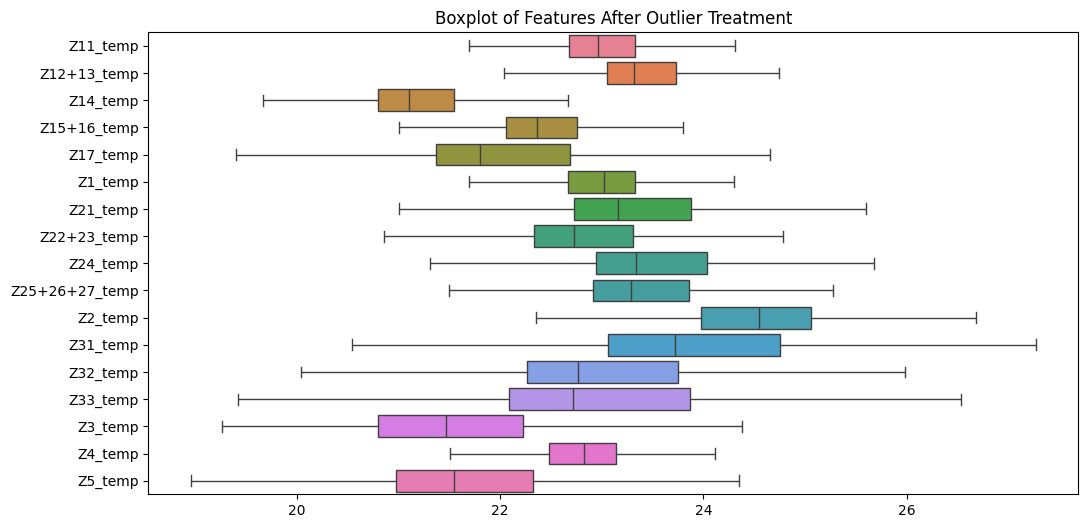

In [11]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df, orient='h')
plt.title('Boxplot of Features After Outlier Treatment')
plt.show()